# The "Broken" Weather Station

Background: A mountain weather station has been offline for months and recently sent a burst of messy data. Before we can use the data and connect it to streamflow, it must be repaired and the Pandas toolkit can support this.

## Task 1: The Raw Feed 
Load the .csv of rainfall values and convert into a Pandas DataFrame named Rainfall_mm. The data can be found here:

```data/snotel_rainfall_data.csv```

Check your work: Use .head() and .describe(). Does the data look right?


In [152]:
import pandas as pd
rainfall = pd.read_csv("data/snotel_rainfall_data.csv")

#print(rainfall.head())
rainfall.describe()

,Date,Precip_in
count,61,58
unique,60,32
top,2024-01-16,0.0
freq,2,27


## Task 2: Using Pandas Tools to make the data readable

**coerce** turns anything it can't read as a number (like 'T' or 'error') into NaN


```df['colname'] = pd.to_numeric(df['colname'], errors='coerce')```

Apply this to your dataset and then try .describe()

In [153]:
rainfall['Precip_in'] = pd.to_numeric(rainfall['Precip_in'], errors='coerce')
rainfall.describe()

,Precip_in
count,56.000000
mean,-8.467089
std,150.395286
min,-999.000000
25%,0.000000
50%,0.050563
75%,0.682890
max,500.000000


## Task 3: Load the discharge data

Load the .csv of rainfall values and convert into a Pandas Dataframe named streamflow_cfs. The data can be found here:

```data/streamflow_data.csv```

Check your work: Use .head() and .describe(). Does the data look right? How can you extract more useful statistics? Show this.

In [154]:
streamflow_cfs = pd.read_csv("data/streamflow_data.csv")
#streamflow_cfs.head()
#streamflow_cfs.describe()

streamflow_cfs['Streamflow_cfs'] = pd.to_numeric(streamflow_cfs['Streamflow_cfs'], errors='coerce')
streamflow_cfs.describe()

,Streamflow_cfs
count,54.000000
mean,40.058333
std,369.096212
min,-999.000000
25%,10.100000
50%,10.600000
75%,13.900000
max,2510.000000


## Task 4: Clean and repair the data

The sensor cut out during the storm and we now have NaN **AND** -999 values. This prevents us from plotting or otherwise using the time series. Are there any other values we should remove?

Explore different methods and select one that fits the data.

Explore .dropna() (delete the gap), .fillna() with the mean, and .interpolate() for a smoother hydrograph for both datasets.

Note, it may be useful to create a new Pandas DataFrame to compare differences. 

In [155]:
#streamflow
stream_drop = streamflow_cfs
stream_drop['Streamflow_cfs'] = stream_drop['Streamflow_cfs'].drop(stream_drop['Streamflow_cfs'].idxmin())
stream_drop = stream_drop.dropna(subset=['Streamflow_cfs'])


stream_fill = streamflow_cfs 
stream_fill['Streamflow_cfs'] = stream_fill['Streamflow_cfs'].fillna(stream_fill['Streamflow_cfs'].mean())


stream_int = streamflow_cfs
stream_int['Streamflow_cfs'] = stream_int['Streamflow_cfs'].interpolate(method = 'linear')


#rainfall
rain_drop = rainfall
rain_drop['Precip_in'] = rain_drop['Precip_in'].drop(rain_drop['Precip_in'].idxmin())
rain_drop = rain_drop.dropna(subset=['Precip_in']) 

rain_fill = rainfall 
rain_fill['Precip_in'] = rain_fill['Precip_in'].fillna(rain_fill['Precip_in'].mean())


rain_int = rainfall
rain_int['Precip_in'] = rain_int['Precip_in'].interpolate(method = 'linear')

## Task 5: Join Pandas DataFrames

We often want to relate data to another, and having all the data in once centralized data frame supports this comparison. Create a new Pandas DataFrame named:
* rainfall_methods fill it with the three rainfall dataframes we cleaned
* streamflow_methods and fill it with the three streamflow dataframes we cleaned


In [188]:
key=["drop","fill","int"]
rainfall_methods = pd.concat([rain_drop, rain_fill, rain_int],keys=key)
print(rainfall_methods.loc[("drop")])

streamflow_methods = pd.concat([stream_drop,stream_fill,stream_int],keys=key)


          Date   Precip_in
0   2024-01-01    0.140280
1   2024-01-02    0.659018
2   2024-01-03    0.000000
3   2024-01-04    0.000000
4   2024-01-05    0.375729
5   2024-01-06    0.000000
6   2024-01-07    1.095458
7   2024-01-08    0.000000
8   2024-01-09    0.000000
9   2024-01-10    0.186576
13  2024-01-14    0.000000
14  2024-01-15    0.385756
15  2024-01-16    0.000000
16  2024-01-16    0.000000
17  2024-01-17    3.380971
18  2024-01-18    0.000000
19  2024-01-19    0.532611
20  2024-01-20    0.000000
21  2024-01-21    0.000000
22  2024-01-22    0.000000
23  2024-01-23    0.000000
24  2024-01-24    0.301443
25  2024-01-25    3.609354
27  2024-01-27    0.370825
28  2024-01-28    0.000000
29  2024-01-29    0.000000
30  2024-01-30    0.151070
31  2024-01-31    1.072686
32  2024-02-01    0.000000
33  2024-02-02    0.000000
34  2024-02-03    0.000000
35  2024-02-04    0.797750
36  2024-02-05    0.000000
37  2024-02-06    0.588250
38  2024-02-07    0.793941
39  2024-02-08    1.317195
4

## Task 6: Plot the rainfall and streamflow data to visualize trends and relationships.

Use Pandas simple plotting functionality to separately plot the two dataframes. Which interpolation method do you like? 

AttributeError: Line2D.set() got an unexpected keyword argument 'r'

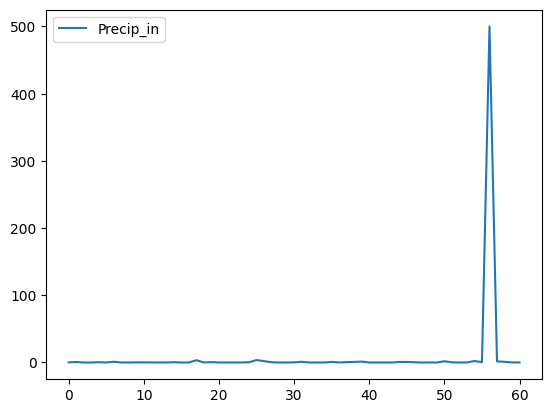

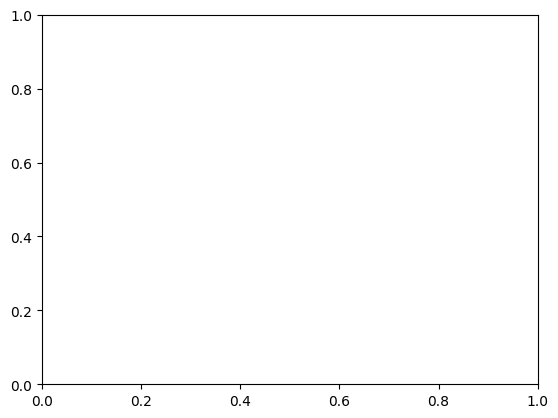

In [ ]:
rainfall_methods.loc[("drop")].plot()
rainfall_methods.loc[("fill")].plot(r=r, color='red')
plt.show()
#streamflow_methods.plot(kind='line',x="Date",y="Streamflow_cfs",figsize=(10,6),title="Streamflow Dataframe",)

## Task 7: Combining DataFrames

From the plots above, choose your most representative gap filling dataframe for rainfall and streamflow, and combine them into a rain_flow_df DataFrame.

## Task 8: Calculate the monthly statistics of the rainfall and discharge

Calculate the monthly total, mean daily (for each month), and the maximum (for each month) rainfall and flow. 

## Task 9: Data Corrections

We want to put the data into a streamflow model, but it requires precipitation to be in mm and streamflow to be in CMS (cubic meters per second). Create a new dataframe called rain_flow_SI_df that converts the previous dataframe to SI units.

## Task 10: Event diagnostics

A key element of hydroinformatics is to identify key events and learn from them. Here, we have two tasks.
* Create a new column and programatically label each day as 'Dry', 'Light Rain', or 'Heavy Rain' based on the precipitaiton colum.
* From our rain_flow_SI_df, create a new Pandas DataFrame called storm_df that programatically selects the streamflow and precipitation data for 5 days before and after the peak flow event.

## Task 11: Quick Data Visualziation

Use the pandas plot function to conduct a quick visualization of precipitation and streamflow. Do they seem coorelated? Any glaring errors?